# Transformer Architectures for Time Series

**Docker image**: `ml4t-gpu`

This notebook compares two modern Transformer variants for time series:
**PatchTST** (patching along time) and **iTransformer** (attention over features).
Both address limitations identified in the Great Debate (Section 13.4).

**Learning Objectives**:
- Implement PatchTST with channel-independent patching
- Implement iTransformer with inverted attention (features as tokens)
- Compare both approaches on ETF return prediction
- Understand when each architecture excels

**Book Reference**: Chapter 13, Section 13.5 (The Transformer's Evolution).
PatchTST: Nie et al. (2023); iTransformer: Liu et al. (2024).

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""Transformer Architectures for Time Series — compare PatchTST and iTransformer on ETF returns."""

import warnings

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from dl_sequences import (
    create_sequences_multi_asset,
    load_dl_dataset,
)
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from sklearn.linear_model import Ridge

from case_studies.config.patchtst.patchtst import PatchTST
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
LOOKBACK = 60
PATCH_SIZE = 6
D_MODEL = 32
N_HEADS = 2
N_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 30
BATCH_SIZE = 128
LR = 0.0005

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)

Using device: cuda


## Data Loading

Load ETF features and labels from the case study pipeline.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = mds.feature_names[:8]
TARGET_COL = mds.label_col

df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Features: {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")
print(f"Rows after dropna: {len(df):,}")

Loaded etfs: 394,233 rows, 71 features, 99 entities, label=fwd_ret_21d
Features: ['ret_5d', 'ret_10d', 'ret_21d', 'ret_42d', 'ret_63d', 'ret_126d', 'ret_189d', 'ret_252d']
Target: fwd_ret_21d
Rows after dropna: 394,157


## Sequence Creation

Both models consume standard `(batch, lookback, n_features)` tensors. PatchTST does
its patching internally — overlapping stride, channel-independent embedding, and
RevIN — rather than requiring pre-patched inputs. iTransformer transposes the same
tensor to treat each feature as a token.

In [5]:
X_reg, y_reg, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
X_reg = np.nan_to_num(X_reg, nan=0.0, posinf=0.0, neginf=0.0)
y_reg = np.nan_to_num(y_reg, nan=0.0)
print(f"Sequences: {X_reg.shape}")

Sequences: (388217, 60, 8)


In [6]:
# Date-based 60/20/20 temporal split: all asset-rows for dates < train_end_date
# go to train, etc. This keeps the cross-section intact within each split,
# unlike sample-order slicing which would split cross-asset.
unique_dates = np.sort(np.unique(timestamps))
train_end_date = unique_dates[int(len(unique_dates) * 0.6)]
val_end_date = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = timestamps < train_end_date
val_mask = (timestamps >= train_end_date) & (timestamps < val_end_date)
test_mask = timestamps >= val_end_date

X_train, y_train = X_reg[train_mask], y_reg[train_mask]
X_val, y_val = X_reg[val_mask], y_reg[val_mask]
X_test, y_test = X_reg[test_mask], y_reg[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

print(f"Train: {len(y_train):,}, Val: {len(y_val):,}, Test: {len(y_test):,}")

Train: 209,996, Val: 89,633, Test: 88,588


### Cross-sectional IC helper

We evaluate every model on the same cross-sectional metric: per-date Spearman
rank correlation between predictions and forward returns, then averaged across
dates. The helper takes flat NumPy arrays so it can be called identically
for the Transformer variants and the Ridge baseline.

In [7]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC across dates."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

> **Note**: This fixed 60/20/20 split is a pedagogical simplification. Production
> deployment requires the walk-forward validation protocol from Chapter 6, where
> the model is retrained on expanding windows to avoid temporal data leakage.

## PatchTST

The paper's PatchTST has three structural properties that must be preserved, or
the model loses its inductive bias and collapses to a generic Transformer on
tokens:

1. **Channel-independent patching.** Each feature channel is treated as its own
   univariate sequence and passed through the same shared Transformer weights.
   No cross-channel mixing inside the encoder. This is the central regularizer.
2. **Overlapping patches.** Stride is smaller than patch length (typically
   `stride = patch_len / 2`), so adjacent patches share timesteps. This keeps
   local temporal context across the patch boundary.
3. **RevIN (Reversible Instance Normalization).** Per-sample per-channel mean/std
   are removed before the backbone and added back after the prediction head,
   making the model robust to distribution shift.

We use the paper authors' reference implementation
(`case_studies.config.patchtst.PatchTST`) directly, wired via a thin scalar-
regression head. This matches the case-study pipelines, so findings in this
chapter and in Section 13.9 use the same model.

In [8]:
# PatchTST imported at the top; instantiate with teaching-scale dimensions.
# The backbone does patching internally — input is raw `(batch, lookback, n_features)`.

## iTransformer

Inverts the attention dimension: treats each **feature** as a token
(rather than each timestep). This lets attention capture cross-variate
dependencies directly.

In [9]:
class iTransformer(nn.Module):
    """iTransformer: attention over features (inverted dimension)."""

    def __init__(self, lookback, n_features, d_model, n_heads, n_layers, dropout):
        super().__init__()
        # Each feature's time series is a token
        self.input_proj = nn.Linear(lookback, d_model)
        self.pos_enc = nn.Parameter(torch.randn(1, n_features, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x):
        # x: (batch, lookback, n_features)
        x = x.permute(0, 2, 1)  # (batch, n_features, lookback)
        x = self.input_proj(x) + self.pos_enc  # (batch, n_features, d_model)
        x = self.encoder(x)
        x = x.mean(dim=1)  # Pool over features
        return self.head(x).squeeze(-1)

## Training

A chunked validation forward keeps full-channel PatchTST in particular from
OOMing on the whole val tensor at once; we reuse the same helper at test
time.

In [10]:
def _chunked_forward(model, X_t, batch_size):
    """Run `model` over `X_t` in batches and concatenate outputs."""
    out = []
    for i in range(0, len(X_t), batch_size):
        out.append(model(X_t[i : i + batch_size]))
    return torch.cat(out, dim=0)

### Training loop

AdamW + cosine schedule + gradient clipping. Early stopping on val loss
with patience=5; we restore the best state before returning. Memory is
released after training so the next model's allocations don't stack on
stale tensors.

In [11]:
def train_model(model, X_tr, y_tr, X_v, y_v, epochs, batch_size, lr):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).to(DEVICE)
    X_v_t = torch.FloatTensor(X_v).to(DEVICE)
    y_v_t = torch.FloatTensor(y_v).to(DEVICE)
    best_val, best_state, patience_counter = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_tr_t))
        epoch_loss, n_b = 0.0, 0
        for i in range(0, len(indices), batch_size):
            idx = indices[i : i + batch_size]
            loss = criterion(model(X_tr_t[idx]), y_tr_t[idx])
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_b += 1
        scheduler.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(_chunked_forward(model, X_v_t, batch_size), y_v_t).item()
        avg_train = epoch_loss / n_b
        history["train_loss"].append(avg_train)
        history["val_loss"].append(val_loss)
        if val_loss < best_val:
            best_val, patience_counter = val_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch + 1}: train={avg_train:.6f}, val={val_loss:.6f}")
        if patience_counter >= 5:
            break
    if best_state:
        model.load_state_dict(best_state)
    del X_tr_t, y_tr_t, X_v_t, y_v_t
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model, history

## Train PatchTST

In [12]:
patchtst = PatchTST(
    n_features=len(FEATURE_COLS),
    lookback=LOOKBACK,
    patch_size=PATCH_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    revin=True,
).to(DEVICE)
n_params = sum(p.numel() for p in patchtst.parameters())
print(f"PatchTST: lookback={LOOKBACK}, patch_size={PATCH_SIZE}, stride={PATCH_SIZE // 2}")
print(f"Parameters: {n_params:,}")

patchtst, hist_patch = train_model(patchtst, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE, LR)

PatchTST: lookback=60, patch_size=6, stride=3
Parameters: 26,940


  Epoch 10: train=0.002601, val=0.004765


## Train iTransformer

In [13]:
print(f"\niTransformer: {len(FEATURE_COLS)} feature tokens, lookback={LOOKBACK}")

itrans = iTransformer(LOOKBACK, len(FEATURE_COLS), D_MODEL, N_HEADS, N_LAYERS, DROPOUT).to(DEVICE)
n_params_i = sum(p.numel() for p in itrans.parameters())
print(f"Parameters: {n_params_i:,}")

itrans, hist_itrans = train_model(itrans, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE, LR)


iTransformer: 8 feature tokens, lookback=60
Parameters: 27,713


### Training Convergence

Comparing validation loss curves reveals how quickly each architecture learns
from the same data. PatchTST's reduced sequence length (patches vs full lookback)
can affect convergence speed.

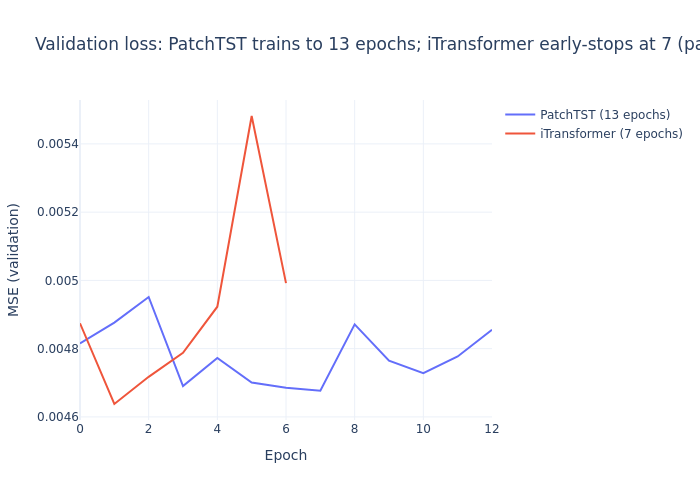

In [14]:
fig = go.Figure()
for name, hist in [("PatchTST", hist_patch), ("iTransformer", hist_itrans)]:
    fig.add_trace(
        go.Scatter(
            y=hist["val_loss"], mode="lines", name=f"{name} ({len(hist['val_loss'])} epochs)"
        )
    )

fig.update_layout(
    title=(
        f"Validation loss: PatchTST trains to {len(hist_patch['val_loss'])} epochs; "
        f"iTransformer early-stops at {len(hist_itrans['val_loss'])} (patience=5)"
    ),
    xaxis_title="Epoch",
    yaxis_title="MSE (validation)",
    template="plotly_white",
)
fig.show()

## Evaluation

We compare both Transformer variants against a Ridge regression baseline
that flattens the lookback window into a single feature vector.

In [15]:
# Transformer predictions
patchtst.eval()
itrans.eval()


def _predict_chunked(model, X, batch_size=BATCH_SIZE):
    """NumPy-array variant of `_chunked_forward` for the test-time evaluator."""
    model.eval()
    X_t = torch.FloatTensor(X).to(DEVICE)
    with torch.no_grad():
        pred = _chunked_forward(model, X_t, batch_size).cpu().numpy()
    del X_t
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pred


pred_patch = _predict_chunked(patchtst, X_test)
pred_itrans = _predict_chunked(itrans, X_test)

In [16]:
# Ridge baseline on flattened sequences. The 8 input features come from
# `load_dl_dataset('etfs')`, which the case-study pipeline already produces in
# z-score units (see `case_studies/etfs/code/08_features.py`). No extra
# StandardScaler step is therefore needed before Ridge — the columns are
# already on a comparable scale across the flattened lookback × feature axis.
X_flat_train = X_train.reshape(len(X_train), -1)
X_flat_test = X_test.reshape(len(X_test), -1)
ridge = Ridge(alpha=1.0)
ridge.fit(X_flat_train, y_train)
pred_ridge = ridge.predict(X_flat_test)

In [17]:
# Compute metrics
results = {}
for name, pred in [("PatchTST", pred_patch), ("iTransformer", pred_itrans), ("Ridge", pred_ridge)]:
    mse = np.mean((pred - y_test) ** 2)
    ic = cross_sectional_ic_mean(y_test, pred, test_dates, test_symbols)
    results[name] = {"mse": mse, "ic": ic}

results_df = pl.DataFrame(
    [{"Model": k, "MSE": v["mse"], "Spearman IC": v["ic"]} for k, v in results.items()]
)
results_df

Model,MSE,Spearman IC
str,f64,f64
"""PatchTST""",0.003493,0.046334
"""iTransformer""",0.003372,0.049805
"""Ridge""",0.003426,0.010052


**Interpretation**: both Transformer variants achieve cross-sectional
Spearman IC well above the Ridge baseline on this 60/20/20 split
(PatchTST 0.046, iTransformer 0.050 vs Ridge 0.010 — roughly a 5× gap).
The two attention designs land close to each other, with iTransformer
marginally ahead here, so the gap *between* them is narrow relative to
their gap over Ridge and the ordering can shift on a different temporal
split. The MSE spread is tighter still (around 0.0034–0.0035 for all
three) because predictions cluster near zero and squared error is
dominated by the irreducible noise floor of forward returns. The
authoritative cross-study ranking comes from the walk-forward evaluation
in Section 13.9, not from this single-split comparison.

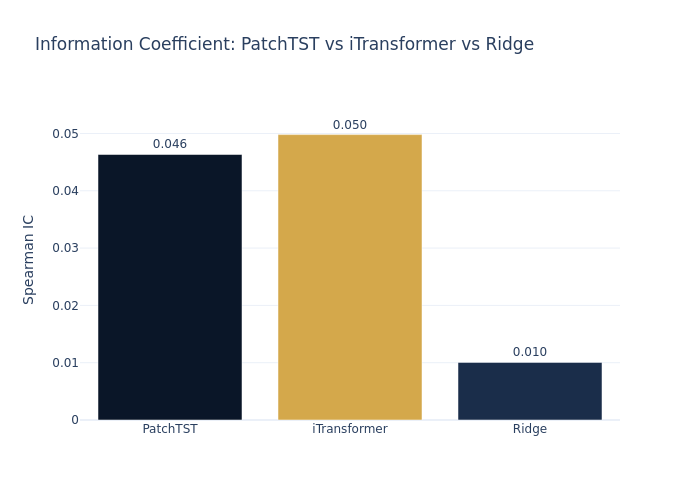

In [18]:
fig = go.Figure()
bar_palette = {
    "PatchTST": COLORS["blue"],
    "iTransformer": COLORS["amber"],
    "Ridge": COLORS["slate"],
}
for name, r in results.items():
    fig.add_trace(
        go.Bar(
            x=[name],
            y=[r["ic"]],
            name=name,
            marker_color=bar_palette.get(name, COLORS["blue"]),
            text=[f"{r['ic']:.3f}"],
            textposition="outside",
        )
    )

fig.update_layout(
    title="Information Coefficient: PatchTST vs iTransformer vs Ridge",
    yaxis_title="Spearman IC",
    template="plotly_white",
    showlegend=False,
)
fig.show()

Both Transformer variants share the same raw lookback tensor; they differ in
which axis attention is applied over — features (iTransformer) or time-patch
tokens (PatchTST). The Ridge baseline on the flattened sequence is the null
model: a linear map with no attention structure at all.

### iTransformer Attention Weights

Because iTransformer applies attention over features (not time steps), the
attention matrix reveals which feature pairs the model considers related.
We extract weights from the first encoder layer to visualize learned
cross-variate dependencies.

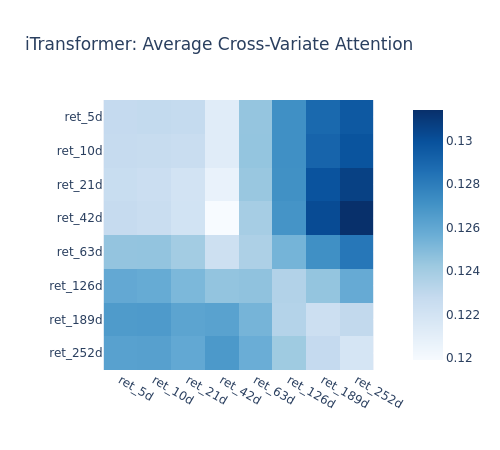

In [19]:
# Extract first-layer attention from iTransformer's self_attn module. Calling
# self_attn with need_weights=True is the supported way to read attention from
# the standard PyTorch TransformerEncoderLayer; we feed the input the encoder
# itself sees (input_proj + pos_enc) so the weights correspond to the same
# computation the model is performing during evaluation.
itrans.eval()
X_sample = torch.FloatTensor(X_test[:256]).to(DEVICE)
with torch.no_grad():
    x_inv = X_sample.permute(0, 2, 1)  # (batch, n_features, lookback)
    x_proj = itrans.input_proj(x_inv) + itrans.pos_enc
    first_layer = itrans.encoder.layers[0]
    _, attn = first_layer.self_attn(x_proj, x_proj, x_proj, need_weights=True)
avg_attn = attn.mean(dim=0).cpu().numpy()  # (n_features, n_features)

fig = px.imshow(
    avg_attn,
    x=FEATURE_COLS,
    y=FEATURE_COLS,
    color_continuous_scale="Blues",
    title="iTransformer: Average Cross-Variate Attention",
)
fig.update_layout(width=500, height=450)
fig.show()

The attention heatmap shows which features the iTransformer relates to each
other. Stronger attention between features suggests the model has learned
meaningful cross-variate dependencies — for instance, momentum and volatility
features may attend strongly to each other if they interact to predict returns.

## sktime Alternative

The custom implementations above provide full control over architecture and
training — useful for understanding the mechanics and for research experiments.
For rapid prototyping, **sktime** wraps PatchTST (and many other architectures)
behind a unified `fit()`/`predict()` interface, handling patching, positional
encoding, and training automatically.

**Dependency note**: sktime's neural forecasters require `neuralforecast`, which
depends on `ray` — and ray does not yet support Python 3.14
([ray-project/ray#56434](https://github.com/ray-project/ray/issues/56434)).
Once ray adds 3.14 wheels, install via `uv pip install neuralforecast`
and uncomment the demo below.

In [20]:
# import pandas as pd
# from sktime.forecasting.patch_tst import PatchTSTForecaster
#
# from data import load_etfs
#
# spy = load_etfs(symbols=["SPY"]).sort("timestamp")
# spy_pd = spy.select(["timestamp", "close"]).to_pandas().set_index("timestamp")["close"]
#
# split = int(len(spy_pd) * 0.8)
# y_train_sk = spy_pd.iloc[:split]
# fh_sk = list(range(1, 11))
#
# forecaster = PatchTSTForecaster(
#     fit_strategy="full",
#     config={
#         "context_length": LOOKBACK,
#         "prediction_length": len(fh_sk),
#         "patch_length": PATCH_SIZE,
#         "patch_stride": PATCH_SIZE // 2,  # match the custom PatchTST stride
#         "d_model": D_MODEL,
#         "num_attention_heads": N_HEADS,
#         "num_hidden_layers": N_LAYERS,
#         "ffn_dim": 4 * D_MODEL,
#         "head_dropout": DROPOUT,
#     },
#     training_args={
#         "num_train_epochs": min(EPOCHS, 10),
#         "per_device_train_batch_size": BATCH_SIZE,
#         "logging_strategy": "no",
#         "save_strategy": "no",
#         "report_to": "none",
#     },
# )
# forecaster.fit(y_train_sk, fh=fh_sk)
# y_pred_sk = forecaster.predict()
# print(f"sktime PatchTST: predicted {len(y_pred_sk)} steps")

The sktime wrapper trades flexibility for convenience: it handles data
preprocessing, training loops, and prediction formatting. For production
pipelines where rapid iteration matters more than architectural
experimentation, this is the recommended starting point.

## Key Takeaways

1. **PatchTST** patches along the time axis, reducing attention complexity from
   $O(L^2)$ to $O((L/P)^2)$ — a dramatic speedup enabling longer lookback windows
2. **iTransformer** inverts the attention dimension: features become tokens, enabling
   direct cross-variate dependency modeling visible in the attention heatmap
3. **Both Transformer variants clearly exceed Ridge but land close to each
   other**: cross-sectional Spearman IC is 0.046 (PatchTST) and 0.050
   (iTransformer) versus 0.010 for the Ridge baseline — roughly a 5× gap
   over the linear model. The two attention designs are within a narrow
   margin of each other on this single 60/20/20 split, so which one leads
   can shift on a different temporal split. The authoritative cross-study
   ranking is the walk-forward evaluation in Section 13.9, not this
   single-split comparison
4. Both represent improvements over vanilla Transformer designs by incorporating
   temporal inductive biases (patching) or sidestepping the temporal order problem
   entirely (inverted attention)
5. **sktime provides native PatchTST** for rapid prototyping via a unified API
6. This notebook evaluates a single ETF universe; cross-dataset comparison in
   `12_case_study_insights` tests whether these patterns generalize

**Next**: See `05_tcn` for temporal convolutional networks.